# Portfolio Optimization Analysis

This notebook provides centralized analysis of Sharpe ratio optimization results from multiple algorithms across different timeframes.

## Optimizers Analyzed:
- **EW**: Equal Weights (Baseline)
- **BF**: Brute Force / SciPy SLSQP
- **GA**: Genetic Algorithm
- **HRP**: Hierarchical Risk Parity (Riskfolio)
- **CQM**: D-Wave Constrained Quadratic Model

## Timeframes:
- **10**: 10 assets
- **100**: 100 assets 
- **full**: Full dataset
- **wide**: Wide dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Define paths and constants
RESULTS_DIR = Path('../../results/sharpe_optimization')
OPTIMIZERS = ['ew', 'bf', 'ga', 'hrp', 'cqm']
TIMEFRAMES = ['10', '100', 'full', 'wide']
NUM_RUNS = 10

# Optimizer display names and colors (matching portfolio_optimization style)
OPTIMIZER_CONFIG = {
    'ew': {'name': 'Equal Weights', 'color': 'blue', 'marker': 'o'},
    'ga': {'name': 'Genetic Algorithm', 'color': 'red', 'marker': 's'},
    'bf': {'name': 'Scipy SLSQP', 'color': 'green', 'marker': '^'},
    'hrp': {'name': 'Hierarchical Risk Parity', 'color': 'orange', 'marker': 'D'},
    'cqm': {'name': 'D-Wave CQM', 'color': 'purple', 'marker': 'X'}
}

# Dataset titles
DATASET_NAMES = {
    '10': '10 Stocks',
    '100': '100 Stocks', 
    'full': 'Full Dataset',
    'wide': 'Wide Dataset'
}

print(f"Results directory: {RESULTS_DIR}")
print(f"Checking if directory exists: {RESULTS_DIR.exists()}")

Results directory: ../../results/sharpe_optimization
Checking if directory exists: True


In [3]:
def read_pickle_dict(file_path):
    """Load pickle file safely"""
    try:
        with open(file_path, 'rb') as f:
            return pickle.load(f)
    except FileNotFoundError:
        return None
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def load_optimizer_data(timeframe, optimizer, num_runs):
    """Load all runs for a specific optimizer and timeframe"""
    runs_data = []
    
    for run in range(num_runs):
        filename = f"results_{timeframe}_{run}_{optimizer}.pkl"
        filepath = RESULTS_DIR / filename
        
        result_data = read_pickle_dict(filepath)
        if result_data is not None:
            portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
            benchmark_returns = result_data.get('benchmark_cumulative_returns', [])
            execution_time = result_data.get('total_run_time', 0)
            start_date = result_data.get('start_date', 'Unknown')
            
            # Check if we have valid data
            if portfolio_returns is not None and len(portfolio_returns) > 0:
                runs_data.append({
                    'run': run,
                    'portfolio_returns': portfolio_returns,
                    'benchmark_returns': benchmark_returns,
                    'execution_time': execution_time,
                    'start_date': start_date
                })
    
    return runs_data

print("Utility functions defined")

Utility functions defined


In [4]:
def plot_timeframe_comparison(timeframe):
    """Plot all optimizers for a given timeframe, showing all runs in the same graph"""
    dataset_name = DATASET_NAMES[timeframe]
    
    # Load data for all optimizers
    all_data = {}
    benchmark_data = None
    
    for optimizer in OPTIMIZERS:
        runs_data = load_optimizer_data(timeframe, optimizer, NUM_RUNS)
        if runs_data:
            all_data[optimizer] = runs_data
            # Store benchmark from first successful load
            if benchmark_data is None and runs_data[0]['benchmark_returns'] is not None:
                benchmark_data = runs_data[0]['benchmark_returns']
    
    if not all_data:
        print(f"⚠️ No data available for {dataset_name}")
        return
    
    # Create the plot
    plt.figure(figsize=(15, 8))
    
    # Plot each optimizer's runs
    for optimizer, runs_data in all_data.items():
        config = OPTIMIZER_CONFIG[optimizer]
        
        for i, run_data in enumerate(runs_data):
            portfolio_returns = run_data['portfolio_returns']
            execution_time = run_data['execution_time']
            
            # Only show label for first run of each optimizer
            label = f"{config['name']} (t={execution_time:.1f}s)" if i == 0 else None
            
            plt.plot(portfolio_returns, 
                    color=config['color'], 
                    linewidth=2, 
                    alpha=0.7,
                    label=label)
    
    # Plot benchmark if available
    if benchmark_data is not None:
        plt.plot(benchmark_data, 
                label='S&P 500 Benchmark', 
                linestyle='--', 
                color='black', 
                linewidth=2, 
                alpha=0.7)
    
    # Formatting
    plt.title(f'Portfolio Optimization Comparison - {dataset_name}\n'
              f'All Runs for Each Optimizer | {len(all_data)} Methods Compared', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Trading Days', fontsize=12)
    plt.ylabel('Cumulative Returns', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{dataset_name} Summary:")
    print("-" * 60)
    
    for optimizer, runs_data in all_data.items():
        config = OPTIMIZER_CONFIG[optimizer]
        final_returns = [run_data['portfolio_returns'][-1] for run_data in runs_data]
        avg_time = np.mean([run_data['execution_time'] for run_data in runs_data])
        
        print(f"{config['name']:<25}: {len(runs_data)} runs, "
              f"avg return: {np.mean(final_returns):>8.4f} ± {np.std(final_returns):.4f}, "
              f"avg time: {avg_time:>6.2f}s")
    
    if benchmark_data is not None:
        benchmark_final = benchmark_data[-1] if len(benchmark_data) > 0 else 0
        print(f"{'S&P 500 Benchmark':<25}: {benchmark_final:>8.4f}")
    
    print()

print("Plotting function defined")

Plotting function defined


🚀 Generating Portfolio Optimization Analysis...


ANALYZING 10 STOCKS


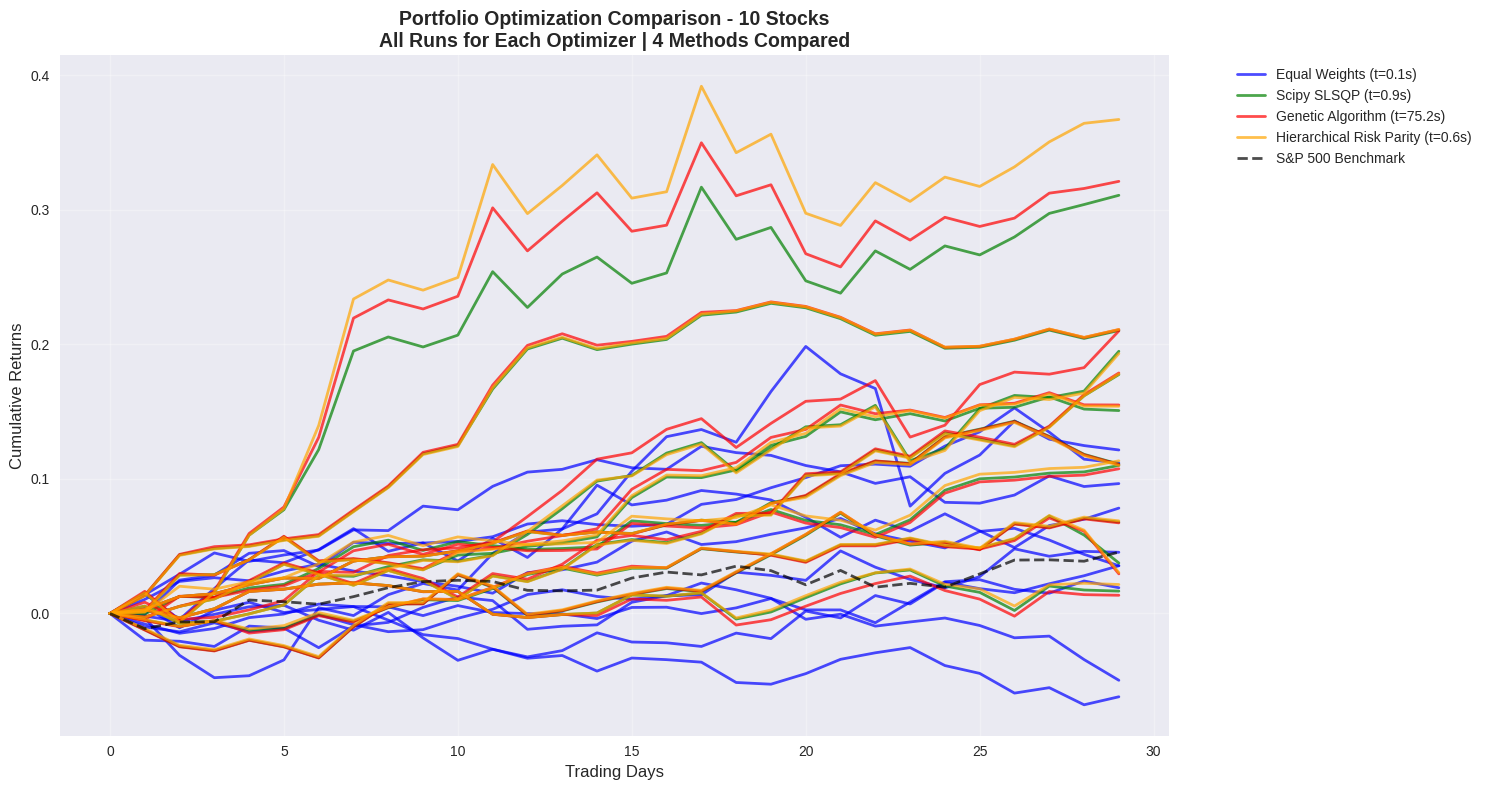


10 Stocks Summary:
------------------------------------------------------------
Equal Weights            : 10 runs, avg return:   0.0432 ± 0.0594, avg time:   0.09s
Scipy SLSQP              : 10 runs, avg return:   0.1387 ± 0.0844, avg time:   0.97s
Genetic Algorithm        : 10 runs, avg return:   0.1404 ± 0.0893, avg time:  74.88s
Hierarchical Risk Parity : 10 runs, avg return:   0.1447 ± 0.0967, avg time:   0.56s
S&P 500 Benchmark        :   0.0456


ANALYZING 100 STOCKS


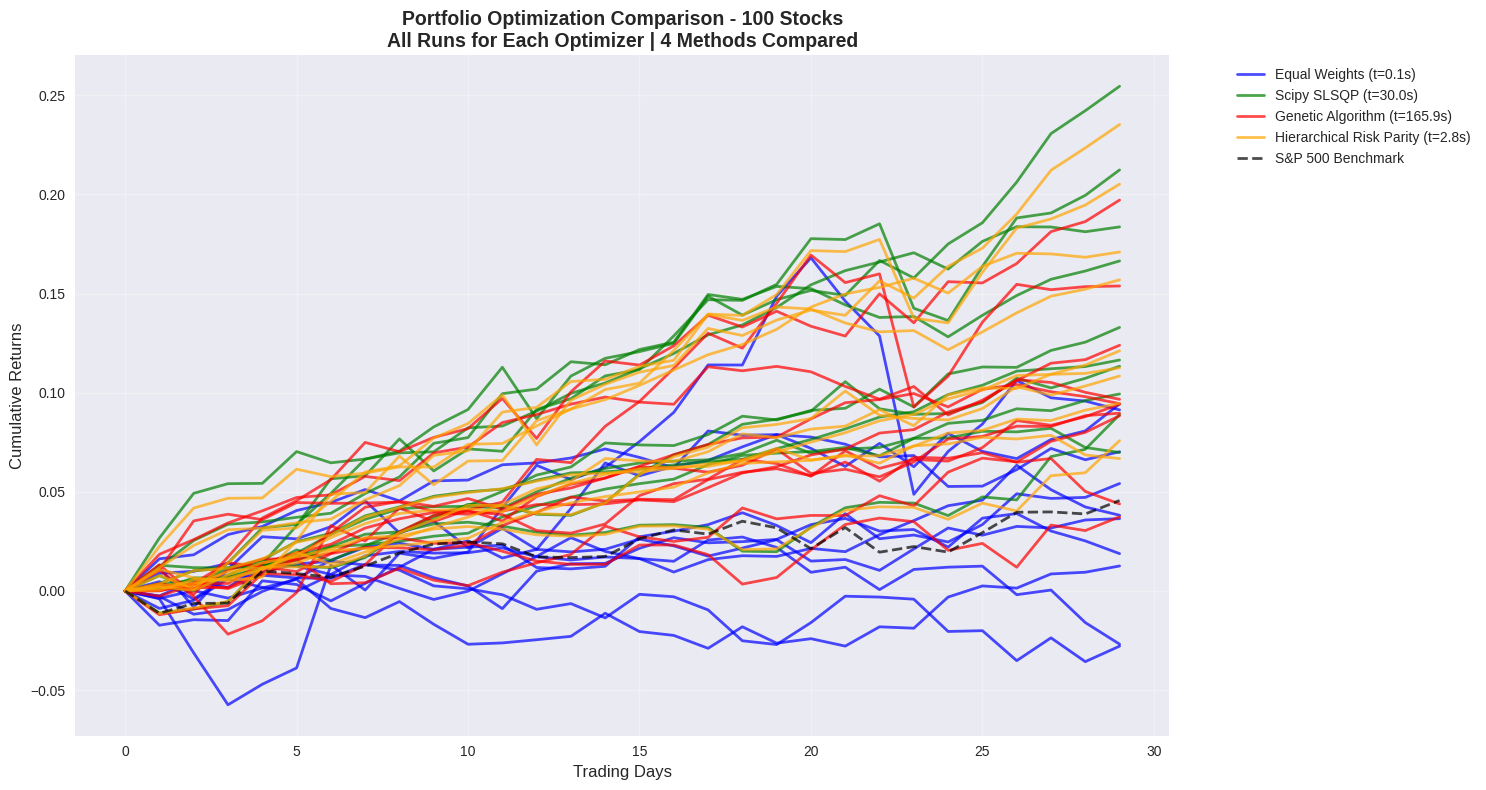


100 Stocks Summary:
------------------------------------------------------------
Equal Weights            : 10 runs, avg return:   0.0361 ± 0.0410, avg time:   0.08s
Scipy SLSQP              : 10 runs, avg return:   0.1438 ± 0.0560, avg time:  35.22s
Genetic Algorithm        : 10 runs, avg return:   0.1019 ± 0.0450, avg time: 164.41s
Hierarchical Risk Parity : 10 runs, avg return:   0.1348 ± 0.0529, avg time:   2.55s
S&P 500 Benchmark        :   0.0456


ANALYZING FULL DATASET


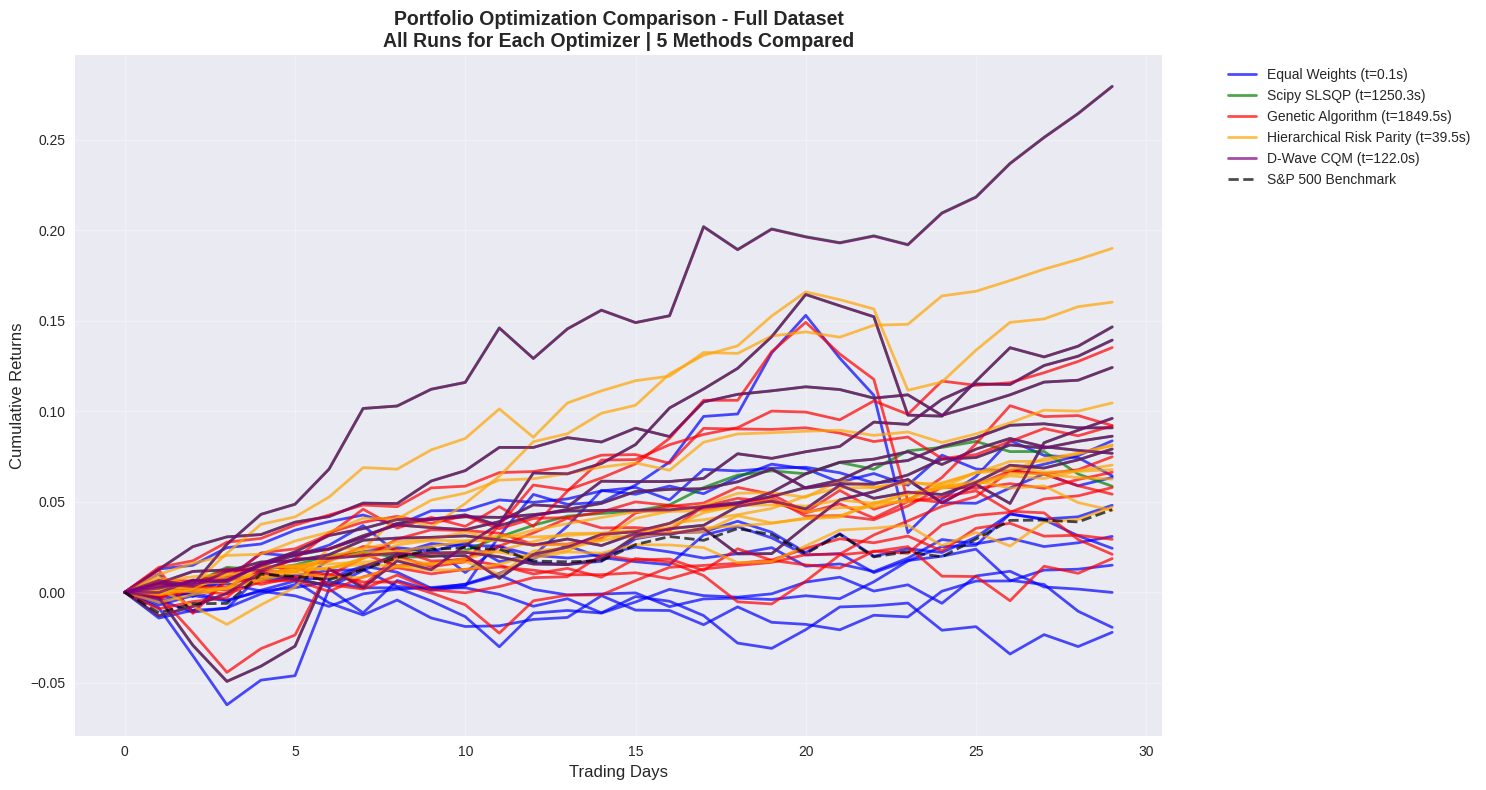


Full Dataset Summary:
------------------------------------------------------------
Equal Weights            : 10 runs, avg return:   0.0288 ± 0.0344, avg time:   0.08s
Scipy SLSQP              : 10 runs, avg return:   0.1177 ± 0.0603, avg time: 1466.61s
Genetic Algorithm        : 10 runs, avg return:   0.0641 ± 0.0346, avg time: 1853.10s
Hierarchical Risk Parity : 10 runs, avg return:   0.0910 ± 0.0456, avg time:  46.68s
D-Wave CQM               : 9 runs, avg return:   0.1242 ± 0.0600, avg time: 125.95s
S&P 500 Benchmark        :   0.0456


ANALYZING WIDE DATASET


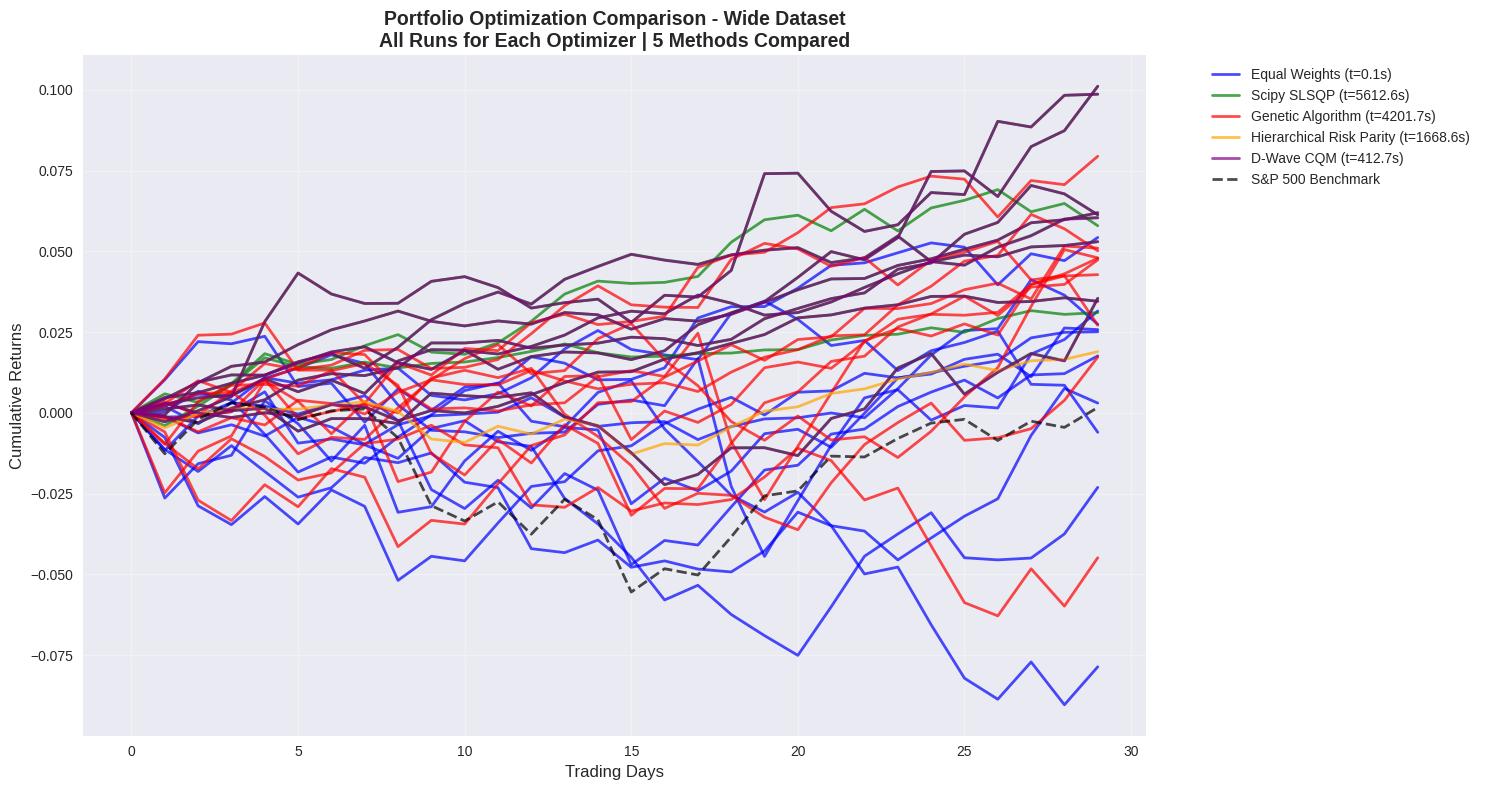


Wide Dataset Summary:
------------------------------------------------------------
Equal Weights            : 10 runs, avg return:   0.0077 ± 0.0353, avg time:   0.11s
Scipy SLSQP              : 10 runs, avg return:   0.0595 ± 0.0231, avg time: 4750.22s
Genetic Algorithm        : 10 runs, avg return:   0.0366 ± 0.0312, avg time: 4215.39s
Hierarchical Risk Parity : 1 runs, avg return:   0.0189 ± 0.0000, avg time: 1668.62s
D-Wave CQM               : 8 runs, avg return:   0.0633 ± 0.0235, avg time: 364.69s
S&P 500 Benchmark        :   0.0016



In [5]:
# Generate plots for all timeframes
print("🚀 Generating Portfolio Optimization Analysis...\n")

for timeframe in TIMEFRAMES:
    print(f"\n{'='*80}")
    print(f"ANALYZING {DATASET_NAMES[timeframe].upper()}")
    print(f"{'='*80}")
    
    plot_timeframe_comparison(timeframe)

In [6]:
# Create comprehensive summary table
def create_comprehensive_summary():
    """Create a comprehensive performance summary across all timeframes and optimizers"""
    summary_data = []
    
    for timeframe in TIMEFRAMES:
        dataset_name = DATASET_NAMES[timeframe]
        
        for optimizer in OPTIMIZERS:
            runs_data = load_optimizer_data(timeframe, optimizer, NUM_RUNS)
            
            if runs_data:
                config = OPTIMIZER_CONFIG[optimizer]
                final_returns = [run_data['portfolio_returns'][-1] for run_data in runs_data]
                execution_times = [run_data['execution_time'] for run_data in runs_data]
                
                summary_data.append({
                    'Dataset': dataset_name,
                    'Optimizer': config['name'],
                    'Runs': len(runs_data),
                    'Avg_Return': np.mean(final_returns),
                    'Std_Return': np.std(final_returns),
                    'Min_Return': np.min(final_returns),
                    'Max_Return': np.max(final_returns),
                    'Avg_Time': np.mean(execution_times),
                    'Success_Rate': len(runs_data) / NUM_RUNS * 100
                })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        
        print("\n" + "=" * 120)
        print("COMPREHENSIVE PERFORMANCE SUMMARY - ALL DATASETS AND OPTIMIZERS")
        print("=" * 120)
        
        # Sort by dataset and return
        df_sorted = df.sort_values(['Dataset', 'Avg_Return'], ascending=[True, False])
        
        # Format for display
        df_display = df_sorted.round(4)
        print(df_display.to_string(index=False))
        
        # Key insights
        print("\n" + "=" * 80)
        print("KEY PERFORMANCE INSIGHTS")
        print("=" * 80)
        
        # Overall best performer
        overall_best = df.loc[df['Avg_Return'].idxmax()]
        print(f"🏆 Best Overall: {overall_best['Optimizer']} on {overall_best['Dataset']} (Return: {overall_best['Avg_Return']:.4f})")
        
        # Fastest method
        fastest = df.loc[df['Avg_Time'].idxmin()]
        print(f"⚡ Fastest Method: {fastest['Optimizer']} on {fastest['Dataset']} (Time: {fastest['Avg_Time']:.2f}s)")
        
        # Most reliable
        most_reliable = df.loc[df['Success_Rate'].idxmax()]
        print(f"🎯 Most Reliable: {most_reliable['Optimizer']} ({most_reliable['Success_Rate']:.1f}% success rate)")
        
        # Performance by dataset
        print("\n📊 BEST PERFORMER BY DATASET:")
        for dataset in df['Dataset'].unique():
            dataset_best = df[df['Dataset'] == dataset].loc[df[df['Dataset'] == dataset]['Avg_Return'].idxmax()]
            print(f"{dataset:<15}: {dataset_best['Optimizer']:<25} (Return: {dataset_best['Avg_Return']:.4f}, Time: {dataset_best['Avg_Time']:.2f}s)")
        
        print("\n" + "=" * 120)
    else:
        print("\n⚠️ No performance data available for comprehensive summary")

# Generate comprehensive summary
create_comprehensive_summary()


COMPREHENSIVE PERFORMANCE SUMMARY - ALL DATASETS AND OPTIMIZERS
     Dataset                Optimizer  Runs  Avg_Return  Std_Return  Min_Return  Max_Return  Avg_Time  Success_Rate
   10 Stocks Hierarchical Risk Parity    10      0.1447      0.0967      0.0215      0.3670    0.5588         100.0
   10 Stocks        Genetic Algorithm    10      0.1404      0.0893      0.0135      0.3210   74.8806         100.0
   10 Stocks              Scipy SLSQP    10      0.1387      0.0844      0.0166      0.3106    0.9732         100.0
   10 Stocks            Equal Weights    10      0.0432      0.0594     -0.0619      0.1215    0.0852         100.0
  100 Stocks              Scipy SLSQP    10      0.1438      0.0560      0.0698      0.2546   35.2211         100.0
  100 Stocks Hierarchical Risk Parity    10      0.1348      0.0529      0.0667      0.2353    2.5473         100.0
  100 Stocks        Genetic Algorithm    10      0.1019      0.0450      0.0374      0.1972  164.4054         100.0
  100 S

## Analysis Complete

This analysis provides a centralized view of all portfolio optimization results across different timeframes and optimizers. Each plot shows all runs for each optimizer on the same graph, making it easy to compare performance and consistency.

### Key Features:
- **Multiple runs visualization**: All runs for each optimizer are plotted together
- **Benchmark comparison**: S&P 500 benchmark included where available
- **Performance metrics**: Execution time and return statistics for each method
- **Comprehensive summary**: Overall performance comparison across all datasets

### Methodology:
- **Equal Weights (EW)**: Simple baseline using equal allocation
- **Genetic Algorithm (GA)**: Evolutionary optimization approach
- **Scipy SLSQP (BF)**: Sequential least squares programming
- **Hierarchical Risk Parity (HRP)**: Risk-based portfolio construction
- **D-Wave CQM**: Quantum-inspired constrained optimization

In [ ]:
# Create individual plots for each timeframe
def create_individual_timeframe_plots():
    """Create separate plots for each timeframe"""
    individual_plots = {}
    
    for timeframe in TIMEFRAMES:
        dataset_name = DATASET_NAMES[timeframe]
        
        # Load data for all optimizers
        all_data = {}
        benchmark_data = None
        
        for optimizer in OPTIMIZERS:
            runs_data = load_optimizer_data(timeframe, optimizer, NUM_RUNS)
            if runs_data:
                all_data[optimizer] = runs_data
                # Store benchmark from first successful load
                if benchmark_data is None and runs_data[0]['benchmark_returns'] is not None:
                    benchmark_data = runs_data[0]['benchmark_returns']
        
        if not all_data:
            print(f"⚠️ No data available for {dataset_name}")
            continue
        
        # Create individual plot
        fig, ax = plt.subplots(figsize=(12, 8))
        
        # Plot each optimizer's runs
        for optimizer, runs_data in all_data.items():
            config = OPTIMIZER_CONFIG[optimizer]
            
            for i, run_data in enumerate(runs_data):
                portfolio_returns = run_data['portfolio_returns']
                execution_time = run_data['execution_time']
                
                # Only show label for first run of each optimizer
                label = f"{config['name']} (t={execution_time:.1f}s)" if i == 0 else None
                
                ax.plot(portfolio_returns, 
                       color=config['color'], 
                       linewidth=2.5, 
                       alpha=0.8,
                       label=label)
        
        # Plot benchmark if available
        if benchmark_data is not None:
            ax.plot(benchmark_data, 
                   label='S&P 500 Benchmark', 
                   linestyle='--', 
                   color='black', 
                   linewidth=2.5, 
                   alpha=0.8)
        
        # Formatting
        ax.set_title(f'{dataset_name} - Portfolio Optimization Results\n'
                    f'All Runs for Each Optimizer | {len(all_data)} Methods Compared', 
                    fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel('Trading Days', fontsize=14)
        ax.set_ylabel('Cumulative Returns', fontsize=14)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Store plot for later use
        individual_plots[timeframe] = {
            'fig': fig,
            'ax': ax,
            'data': all_data,
            'benchmark': benchmark_data
        }
        
        plt.tight_layout()
        plt.show()
        
        # Print summary for this timeframe
        print(f"\n{dataset_name} Performance Summary:")
        print("-" * 70)
        
        for optimizer, runs_data in all_data.items():
            config = OPTIMIZER_CONFIG[optimizer]
            final_returns = [run_data['portfolio_returns'][-1] for run_data in runs_data]
            avg_time = np.mean([run_data['execution_time'] for run_data in runs_data])
            
            print(f"{config['name']:<30}: {len(runs_data)} runs, "
                  f"avg return: {np.mean(final_returns):>8.4f} ± {np.std(final_returns):.4f}, "
                  f"avg time: {avg_time:>6.2f}s")
        
        if benchmark_data is not None:
            benchmark_final = benchmark_data[-1] if len(benchmark_data) > 0 else 0
            print(f"{'S&P 500 Benchmark':<30}: {benchmark_final:>8.4f}")
        
        print()
    
    return individual_plots

# Generate individual plots
print("🚀 Creating Individual Timeframe Plots...\n")
individual_plots = create_individual_timeframe_plots()

In [ ]:
# Create comprehensive multiplot with all timeframes
def create_comprehensive_multiplot():
    """Create a large multiplot showing all timeframes in the same figure"""
    # Set up the subplot configuration
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    # Create plots for each timeframe
    plot_data = {}
    
    for idx, timeframe in enumerate(TIMEFRAMES):
        if idx >= len(axes):
            break
            
        dataset_name = DATASET_NAMES[timeframe]
        ax = axes[idx]
        
        # Load data for all optimizers
        all_data = {}
        benchmark_data = None
        
        for optimizer in OPTIMIZERS:
            runs_data = load_optimizer_data(timeframe, optimizer, NUM_RUNS)
            if runs_data:
                all_data[optimizer] = runs_data
                # Store benchmark from first successful load
                if benchmark_data is None and runs_data[0]['benchmark_returns'] is not None:
                    benchmark_data = runs_data[0]['benchmark_returns']
        
        if not all_data:
            ax.text(0.5, 0.5, f'No data available\nfor {dataset_name}', 
                   ha='center', va='center', transform=ax.transAxes,
                   fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))
            ax.set_title(f'{dataset_name}', fontsize=14, fontweight='bold')
            continue
        
        # Plot each optimizer's runs
        legend_handles = []
        legend_labels = []
        
        for optimizer, runs_data in all_data.items():
            config = OPTIMIZER_CONFIG[optimizer]
            
            # Calculate average performance for cleaner visualization
            all_returns = []
            avg_time = np.mean([run_data['execution_time'] for run_data in runs_data])
            
            for run_data in runs_data:
                portfolio_returns = run_data['portfolio_returns']
                all_returns.append(portfolio_returns)
            
            # Plot all individual runs with transparency
            for i, returns in enumerate(all_returns):
                ax.plot(returns, 
                       color=config['color'], 
                       linewidth=1.5, 
                       alpha=0.4)
            
            # Plot average line with better visibility
            if all_returns:
                # Calculate mean performance across runs
                max_length = max(len(returns) for returns in all_returns)
                padded_returns = []
                for returns in all_returns:
                    if len(returns) < max_length:
                        # Pad with last value
                        padded = list(returns) + [returns[-1]] * (max_length - len(returns))
                        padded_returns.append(padded)
                    else:
                        padded_returns.append(returns)
                
                mean_returns = np.mean(padded_returns, axis=0)
                line = ax.plot(mean_returns, 
                              color=config['color'], 
                              linewidth=3, 
                              alpha=0.9,
                              label=f"{config['name']} (avg)")
                
                legend_handles.append(line[0])
                legend_labels.append(f"{config['name']} (t={avg_time:.1f}s)")
        
        # Plot benchmark if available
        if benchmark_data is not None:
            line = ax.plot(benchmark_data, 
                          label='S&P 500 Benchmark', 
                          linestyle='--', 
                          color='black', 
                          linewidth=2.5, 
                          alpha=0.8)
            legend_handles.append(line[0])
            legend_labels.append('S&P 500 Benchmark')
        
        # Formatting for each subplot
        ax.set_title(f'{dataset_name}\n({len(all_data)} Methods, {sum(len(data) for data in all_data.values())} Total Runs)', 
                    fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Trading Days', fontsize=12)
        ax.set_ylabel('Cumulative Returns', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Add legend only to first subplot to avoid cluttering
        if idx == 0:
            ax.legend(legend_handles, legend_labels, loc='upper left', fontsize=10)
        
        # Store data for cross-timeframe analysis
        plot_data[timeframe] = {
            'data': all_data,
            'benchmark': benchmark_data
        }
    
    # Add overall title
    fig.suptitle('Portfolio Optimization Results - All Timeframes Comparison\n'
                 'Individual Runs (Transparent) + Average Performance (Bold Lines)', 
                 fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)
    plt.show()
    
    return plot_data

# Create the comprehensive multiplot
print("🚀 Creating Comprehensive Multiplot with All Timeframes...\n")
multiplot_data = create_comprehensive_multiplot()

In [ ]:
# Cross-timeframe analysis
def create_cross_timeframe_analysis():
    """Analyze performance patterns across different timeframes"""
    
    # Collect data across all timeframes
    performance_matrix = {}
    execution_times = {}
    
    for timeframe in TIMEFRAMES:
        performance_matrix[timeframe] = {}
        execution_times[timeframe] = {}
        
        for optimizer in OPTIMIZERS:
            runs_data = load_optimizer_data(timeframe, optimizer, NUM_RUNS)
            
            if runs_data:
                final_returns = [run_data['portfolio_returns'][-1] for run_data in runs_data]
                times = [run_data['execution_time'] for run_data in runs_data]
                
                performance_matrix[timeframe][optimizer] = {
                    'mean': np.mean(final_returns),
                    'std': np.std(final_returns),
                    'count': len(runs_data)
                }
                execution_times[timeframe][optimizer] = {
                    'mean': np.mean(times),
                    'std': np.std(times)
                }
    
    # Create performance comparison heatmaps
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Performance heatmap
    perf_data = []
    time_data = []
    optimizer_labels = []
    timeframe_labels = []
    
    for optimizer in OPTIMIZERS:
        if optimizer in OPTIMIZER_CONFIG:
            optimizer_labels.append(OPTIMIZER_CONFIG[optimizer]['name'])
            perf_row = []
            time_row = []
            
            for timeframe in TIMEFRAMES:
                if timeframe not in timeframe_labels:
                    timeframe_labels.append(DATASET_NAMES[timeframe])
                
                if timeframe in performance_matrix and optimizer in performance_matrix[timeframe]:
                    perf_row.append(performance_matrix[timeframe][optimizer]['mean'])
                    time_row.append(execution_times[timeframe][optimizer]['mean'])
                else:
                    perf_row.append(np.nan)
                    time_row.append(np.nan)
            
            perf_data.append(perf_row)
            time_data.append(time_row)
    
    # Only keep timeframe labels for the first time
    timeframe_labels = [DATASET_NAMES[tf] for tf in TIMEFRAMES]
    
    # Performance heatmap
    perf_array = np.array(perf_data)
    im1 = ax1.imshow(perf_array, cmap='RdYlGn', aspect='auto')
    ax1.set_title('Average Portfolio Returns\nAcross Timeframes and Optimizers', 
                  fontsize=14, fontweight='bold', pad=20)
    ax1.set_xlabel('Dataset Size / Timeframe', fontsize=12)
    ax1.set_ylabel('Optimization Method', fontsize=12)
    
    # Add colorbar for performance
    cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
    cbar1.set_label('Average Return', fontsize=12)
    
    # Set ticks and labels
    ax1.set_xticks(range(len(timeframe_labels)))
    ax1.set_xticklabels(timeframe_labels, rotation=45, ha='right')
    ax1.set_yticks(range(len(optimizer_labels)))
    ax1.set_yticklabels(optimizer_labels)
    
    # Add text annotations for performance
    for i in range(len(optimizer_labels)):
        for j in range(len(timeframe_labels)):
            if not np.isnan(perf_array[i, j]):
                ax1.text(j, i, f'{perf_array[i, j]:.3f}', 
                        ha='center', va='center', fontsize=10, fontweight='bold',
                        color='white' if perf_array[i, j] < np.nanmean(perf_array) else 'black')
    
    # Execution time heatmap
    time_array = np.array(time_data)
    # Use log scale for better visualization of execution times
    log_time_array = np.log10(time_array + 1e-6)  # Add small constant to avoid log(0)
    im2 = ax2.imshow(log_time_array, cmap='YlOrRd', aspect='auto')
    ax2.set_title('Average Execution Times (Log Scale)\nAcross Timeframes and Optimizers', 
                  fontsize=14, fontweight='bold', pad=20)
    ax2.set_xlabel('Dataset Size / Timeframe', fontsize=12)
    ax2.set_ylabel('Optimization Method', fontsize=12)
    
    # Add colorbar for execution time
    cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8)
    cbar2.set_label('Log₁₀(Execution Time) [seconds]', fontsize=12)
    
    # Set ticks and labels
    ax2.set_xticks(range(len(timeframe_labels)))
    ax2.set_xticklabels(timeframe_labels, rotation=45, ha='right')
    ax2.set_yticks(range(len(optimizer_labels)))
    ax2.set_yticklabels(optimizer_labels)
    
    # Add text annotations for execution times
    for i in range(len(optimizer_labels)):
        for j in range(len(timeframe_labels)):
            if not np.isnan(time_array[i, j]):
                ax2.text(j, i, f'{time_array[i, j]:.1f}s', 
                        ha='center', va='center', fontsize=10, fontweight='bold',
                        color='white' if log_time_array[i, j] > np.nanmean(log_time_array) else 'black')
    
    plt.tight_layout()
    plt.show()
    
    # Print scalability analysis
    print("\n" + "=" * 80)
    print("SCALABILITY ANALYSIS - PERFORMANCE VS DATASET SIZE")
    print("=" * 80)
    
    print("\n📈 PERFORMANCE TRENDS:")
    for optimizer in OPTIMIZERS:
        if optimizer in OPTIMIZER_CONFIG:
            config = OPTIMIZER_CONFIG[optimizer]
            print(f"\n{config['name']}:")
            
            returns = []
            times = []
            datasets = []
            
            for timeframe in TIMEFRAMES:
                if (timeframe in performance_matrix and 
                    optimizer in performance_matrix[timeframe]):
                    
                    perf = performance_matrix[timeframe][optimizer]['mean']
                    time_val = execution_times[timeframe][optimizer]['mean']
                    
                    returns.append(perf)
                    times.append(time_val)
                    datasets.append(DATASET_NAMES[timeframe])
                    
                    print(f"  {DATASET_NAMES[timeframe]:<15}: Return={perf:>7.4f}, Time={time_val:>8.2f}s")
            
            # Calculate trends if we have enough data points
            if len(returns) >= 3:
                # Simple trend analysis
                if returns[0] > returns[-1]:
                    trend = "📉 Declining"
                elif returns[0] < returns[-1]:
                    trend = "📈 Improving" 
                else:
                    trend = "➡️ Stable"
                
                time_trend = "⚡ Faster" if times[0] > times[-1] else "🐌 Slower"
                print(f"  → Performance trend: {trend}")
                print(f"  → Speed trend: {time_trend}")
    
    print("\n" + "=" * 80)
    print("KEY INSIGHTS")
    print("=" * 80)
    
    # Find best performer for each timeframe
    print("\n🏆 BEST PERFORMER BY DATASET SIZE:")
    for timeframe in TIMEFRAMES:
        if timeframe in performance_matrix:
            best_optimizer = None
            best_performance = -np.inf
            
            for optimizer in performance_matrix[timeframe]:
                perf = performance_matrix[timeframe][optimizer]['mean']
                if perf > best_performance:
                    best_performance = perf
                    best_optimizer = optimizer
            
            if best_optimizer:
                config = OPTIMIZER_CONFIG[best_optimizer]
                print(f"{DATASET_NAMES[timeframe]:<15}: {config['name']:<30} (Return: {best_performance:.4f})")
    
    # Performance vs Time efficiency
    print("\n⚖️ EFFICIENCY ANALYSIS (Return per Second):")
    efficiency_data = []
    
    for optimizer in OPTIMIZERS:
        if optimizer in OPTIMIZER_CONFIG:
            config = OPTIMIZER_CONFIG[optimizer]
            total_efficiency = 0
            count = 0
            
            for timeframe in TIMEFRAMES:
                if (timeframe in performance_matrix and 
                    optimizer in performance_matrix[timeframe] and
                    timeframe in execution_times and
                    optimizer in execution_times[timeframe]):
                    
                    perf = performance_matrix[timeframe][optimizer]['mean']
                    time_val = execution_times[timeframe][optimizer]['mean']
                    
                    if time_val > 0:
                        efficiency = perf / time_val
                        total_efficiency += efficiency
                        count += 1
            
            if count > 0:
                avg_efficiency = total_efficiency / count
                efficiency_data.append((config['name'], avg_efficiency))
    
    # Sort by efficiency
    efficiency_data.sort(key=lambda x: x[1], reverse=True)
    
    for name, efficiency in efficiency_data:
        print(f"{name:<30}: {efficiency:.6f} return/second")

# Run cross-timeframe analysis
print("🚀 Running Cross-Timeframe Analysis...\n")
create_cross_timeframe_analysis()